In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set_theme()

In [13]:
stroke_dset = pd.read_csv(r"C:\Users\HomePC\Documents\Data\TechCrush\Capstone\healthcare-dataset-stroke-data.csv")

stroke_dset

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [14]:
#checking the size of the dataset
stroke_dset.shape

(5110, 12)

There are 5110 rows and 12 columns present in the original dataset

In [15]:
#Having an initial inspection of the dataset
stroke_dset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


It is observed that age column is a float, which needs to be coverted to integer while
BMI colum has missing values.

In [16]:
#checking the sum of the missing values in each column
stroke_dset.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

This affirms that BMI column has missing values of 201

## 1. Data Cleaning

In [17]:
#Changing the initials of each column to capital for better formatting and readability

stroke_dset.columns = stroke_dset.columns.str.replace("_"," ").str.strip().str.title()

In [18]:
stroke_dset.columns

Index(['Id', 'Gender', 'Age', 'Hypertension', 'Heart Disease', 'Ever Married',
       'Work Type', 'Residence Type', 'Avg Glucose Level', 'Bmi',
       'Smoking Status', 'Stroke'],
      dtype='str')

In [19]:
#Dropping the ID column, it is not needed in the model building

stroke_dset.drop(['Id'], axis= 1,inplace = True)

##### ID does not contribute to prediction, so removing it prevents noise in the model

In [20]:
stroke_dset.head()

,Gender,Age,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Avg Glucose Level,Bmi,Smoking Status,Stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


##### From the above, the Id column has dropped

In [21]:
#checking for duplicated values

stroke_dset.duplicated().sum()

np.int64(0)

##### The Age column has been converted from float to integer using the code below

In [22]:
#changing the Age column from float to int
stroke_dset['Age'] = stroke_dset['Age'].astype('int')

In [23]:
stroke_dset['Age'].dtypes

dtype('int64')

In [24]:
stroke_dset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             5110 non-null   str    
 1   Age                5110 non-null   int64  
 2   Hypertension       5110 non-null   int64  
 3   Heart Disease      5110 non-null   int64  
 4   Ever Married       5110 non-null   str    
 5   Work Type          5110 non-null   str    
 6   Residence Type     5110 non-null   str    
 7   Avg Glucose Level  5110 non-null   float64
 8   Bmi                4909 non-null   float64
 9   Smoking Status     5110 non-null   str    
 10  Stroke             5110 non-null   int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 439.3 KB


In [25]:
#checking the percentage of the missing values in each column

missing_percentage =((stroke_dset.isnull().sum()/len(stroke_dset))*100).sort_values(ascending=False)
missing_percentage

Bmi                  3.933464
Age                  0.000000
Gender               0.000000
Hypertension         0.000000
Heart Disease        0.000000
Work Type            0.000000
Ever Married         0.000000
Residence Type       0.000000
Avg Glucose Level    0.000000
Smoking Status       0.000000
Stroke               0.000000
dtype: float64

##### From the results, BMI is the only column with missing values, accounting for approximately **4%** of the dataset. Given that BMI is an important predictor of stroke and the proportion of missing data is relatively small, it is unlikely to substantially affect the analysis or predictive performance. Therefore, the column will be retained, and the missing values will be appropriately imputed.

In [26]:
# Filling the missing values in Bmi with median of the column
stroke_dset['Bmi'] = stroke_dset['Bmi'].fillna(stroke_dset['Bmi'].median())


In [27]:
stroke_dset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             5110 non-null   str    
 1   Age                5110 non-null   int64  
 2   Hypertension       5110 non-null   int64  
 3   Heart Disease      5110 non-null   int64  
 4   Ever Married       5110 non-null   str    
 5   Work Type          5110 non-null   str    
 6   Residence Type     5110 non-null   str    
 7   Avg Glucose Level  5110 non-null   float64
 8   Bmi                5110 non-null   float64
 9   Smoking Status     5110 non-null   str    
 10  Stroke             5110 non-null   int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 439.3 KB


## Outlier Detection 

In [28]:
# selecting three numeric columns
#selected the Age, Avg Glucose Level, and BMI columns for outlier checking because the other numeric variables are binary

selected_numeric_columns = stroke_dset[['Age','Avg Glucose Level','Bmi']]
selected_numeric_columns
                           

,Age,Avg Glucose Level,Bmi
0,67,228.69,36.6
1,61,202.21,28.1
2,80,105.92,32.5
3,49,171.23,34.4
4,79,174.12,24.0
...,...,...,...
5105,80,83.75,28.1
5106,81,125.20,40.0
5107,35,82.99,30.6
5108,51,166.29,25.6


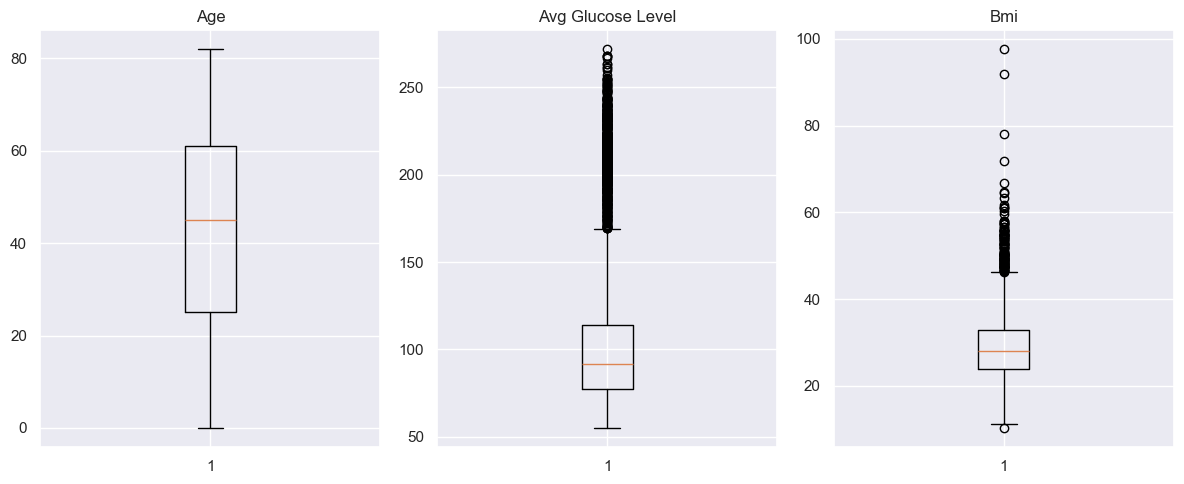

In [102]:
# Plotting a boxplot to determine if there is presence of an outlier in numeric selected columns
plt.figure(figsize=(12,5))

for i, column in enumerate(selected_numeric_columns.columns, 1):
    plt.subplot(1, 3, i)
    plt.boxplot(selected_numeric_columns[column])
    plt.title(column)

plt.tight_layout()
plt.show()

##### The Age column does not contain any outliers. However, Avg Glucose Level and BMI show potential outliers that require further investigation.

## Further Comfirming the Outliers using IQR

In [30]:
# Step 1: Calculate Q1 and Q3 in Avg Glucose Level

Q1 = stroke_dset['Avg Glucose Level'].quantile(0.25)
Q3 = stroke_dset['Avg Glucose Level'].quantile(0.75)
# Step 2: Calculate IQR
IQR = Q3 - Q1
# Step 3: Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Step 4: Display results
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Q1: 77.245
Q3: 114.09
IQR: 36.845
Lower Bound: 21.977500000000006
Upper Bound: 169.35750000000002


In [31]:
# Taking the description of Avg Gloucose Level
stroke_dset['Avg Glucose Level'].describe()

count    5110.000000
mean      106.147677
std        45.283560
min        55.120000
25%        77.245000
50%        91.885000
75%       114.090000
max       271.740000
Name: Avg Glucose Level, dtype: float64

##### 271.74 is far above 169.36. Yes, there are likely high-end outliers in Avg Glucose Level. But this makes sense medically because extremely high glucose levels can occur, therefore, i won't be removing them


In [32]:
# Step 1: Calculate Q1 and Q3 in Bmi

Q1 = stroke_dset['Bmi'].quantile(0.25)
Q3 = stroke_dset['Bmi'].quantile(0.75)
# Step 2: Calculate IQR
IQR = Q3 - Q1
# Step 3: Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Step 4: Display results
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Q1: 23.8
Q3: 32.8
IQR: 8.999999999999996
Lower Bound: 10.300000000000006
Upper Bound: 46.29999999999999


In [33]:
stroke_dset['Bmi'].describe()

count    5110.000000
mean       28.862035
std         7.699562
min        10.300000
25%        23.800000
50%        28.100000
75%        32.800000
max        97.600000
Name: Bmi, dtype: float64

##### The maximum BMI value of **97.6** is far above the upper IQR bound of **46.29**, indicating the presence of strong upper outliers. However, similar to Avg Glucose Level, extremely high BMI values are medically possible and are known risk factors for stroke. Therefore, these values may represent genuine clinical cases rather than data entry errors.

#### Let's have an overview of the statistical data for numerical columns only.

In [34]:
stroke_dset.describe()

,Age,Hypertension,Heart Disease,Avg Glucose Level,Bmi,Stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,43.215264,0.097456,0.054012,106.147677,28.862035,0.048728
std,22.633866,0.296607,0.226063,45.283560,7.699562,0.215320
min,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


We can see that the minimum age is 0 and this is because there are children under age 1 included in our dataset.

Next, check for the different object columns we have and the values they contain.

In [36]:
stroke_dset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             5110 non-null   str    
 1   Age                5110 non-null   int64  
 2   Hypertension       5110 non-null   int64  
 3   Heart Disease      5110 non-null   int64  
 4   Ever Married       5110 non-null   str    
 5   Work Type          5110 non-null   str    
 6   Residence Type     5110 non-null   str    
 7   Avg Glucose Level  5110 non-null   float64
 8   Bmi                5110 non-null   float64
 9   Smoking Status     5110 non-null   str    
 10  Stroke             5110 non-null   int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 439.3 KB


In [37]:
stroke_dset["Gender"].value_counts()

Gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [38]:
filtered_gender = stroke_dset[stroke_dset["Gender"] == "Other"]
filtered_gender

,Gender,Age,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Avg Glucose Level,Bmi,Smoking Status,Stroke
3116,Other,26,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0


From the two lines of code above, we see that there is another value known as "Other" in the gender column. Since this may result in a huge variation and we have only one value with the gender as"other", it is necessary we drop the column so as not to introduce any form of noise to our model.

In [39]:
stroke_dset.drop(index=3116, inplace=True)

In [40]:
stroke_dset.info()

<class 'pandas.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             5109 non-null   str    
 1   Age                5109 non-null   int64  
 2   Hypertension       5109 non-null   int64  
 3   Heart Disease      5109 non-null   int64  
 4   Ever Married       5109 non-null   str    
 5   Work Type          5109 non-null   str    
 6   Residence Type     5109 non-null   str    
 7   Avg Glucose Level  5109 non-null   float64
 8   Bmi                5109 non-null   float64
 9   Smoking Status     5109 non-null   str    
 10  Stroke             5109 non-null   int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 479.0 KB


In [41]:
stroke_dset["Gender"].value_counts()

Gender
Female    2994
Male      2115
Name: count, dtype: int64

In [43]:
stroke_dset["Residence Type"].value_counts()

Residence Type
Urban    2596
Rural    2513
Name: count, dtype: int64

In [44]:
stroke_dset["Ever Married"].value_counts()

Ever Married
Yes    3353
No     1756
Name: count, dtype: int64

In [45]:
stroke_dset["Smoking Status"].value_counts()

Smoking Status
never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: count, dtype: int64

In [47]:
stroke_dset["Work Type"].value_counts()

Work Type
Private          2924
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

In [49]:
stroke_dset["Stroke"].value_counts()

Stroke
0    4860
1     249
Name: count, dtype: int64

From the exploration above, we can see that the Residence type, Marital status, Smoking status and even work type have reasonable amount of data in the categories(/values) under them. Unlike the previous gender data, there will be no need to deop any row.

However, the stroke column shows us an imbalance. There are more people with stroke than without stroke despite important factors like residence type that greatly contributes to the cardiac health of residents, work type and even smoking status. Althought this will be addressed in the model building and fine tuning.

Now, let's visualise the dataset

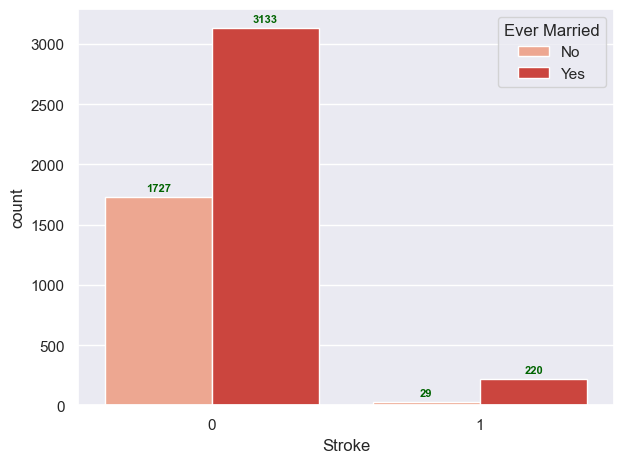

In [106]:
bars= sns.countplot(data = stroke_dset, x= "Stroke", palette= "Reds", hue ="Ever Married",  legend=True)

for i in bars.containers:
  bars.bar_label(i, padding=3, color="darkgreen",fontweight="bold", fontsize= 8)

plt.tight_layout()

plt.show()

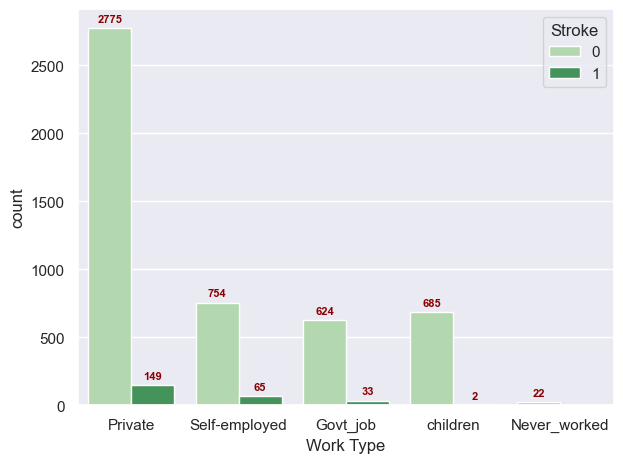

In [104]:
bars= sns.countplot(data = stroke_dset, x= "Work Type", palette= "Greens", hue ="Stroke",  legend=True)

for i in bars.containers:
  bars.bar_label(i, padding=3, color="darkred",fontweight="bold", fontsize= 8)

plt.tight_layout()

plt.show()

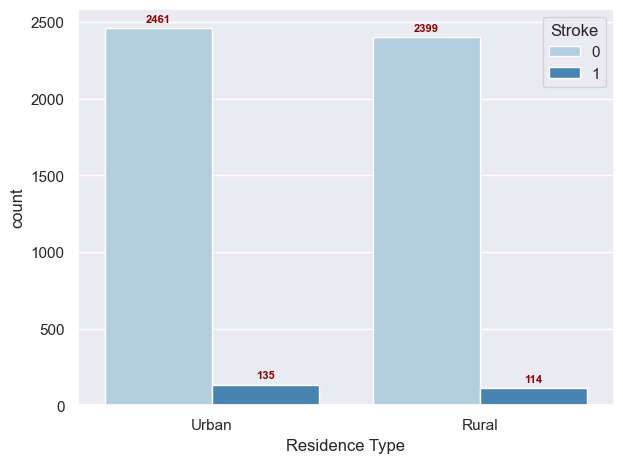

In [59]:
bars= sns.countplot(data = stroke_dset, x= "Residence Type", palette= "Blues", hue ="Stroke",  legend=True)

for i in bars.containers:
  bars.bar_label(i, padding=3, color="darkred",fontweight="bold", fontsize= 8)

plt.tight_layout()

plt.show()

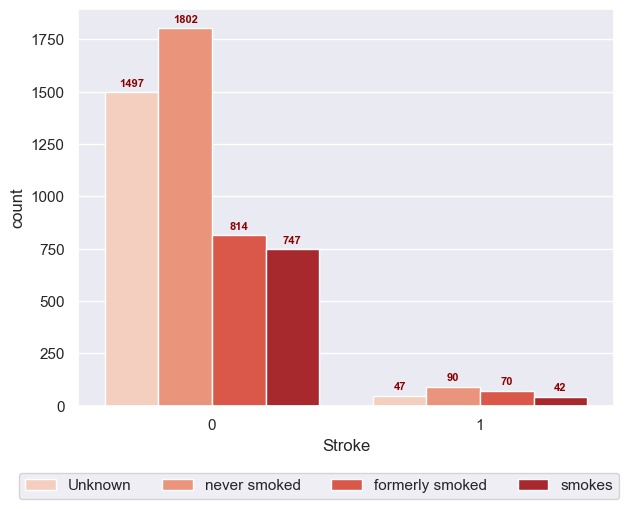

In [79]:
bars= sns.countplot(data = stroke_dset, x= "Stroke", palette= "Reds", hue ="Smoking Status",  legend=True)

for i in bars.containers:
  bars.bar_label(i, padding=3, color="darkred",fontweight="bold", fontsize= 8)

plt.tight_layout()
plt.legend(ncol= 4, bbox_to_anchor=(.45, -.15), loc="upper center")
plt.show()

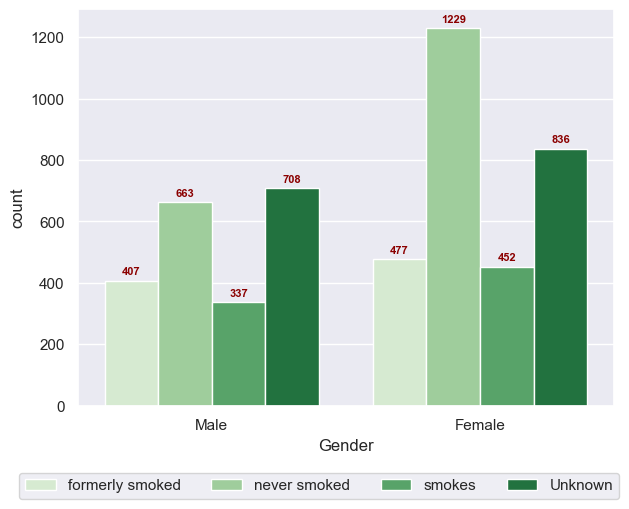

In [80]:
bars= sns.countplot(data = stroke_dset, x= "Gender", palette= "Greens", hue ="Smoking Status",  legend=True)

for i in bars.containers:
  bars.bar_label(i, padding=3, color="darkred",fontweight="bold", fontsize= 8)

plt.tight_layout()
plt.legend(ncol= 4, bbox_to_anchor=(.45, -.15), loc="upper center")

plt.show()

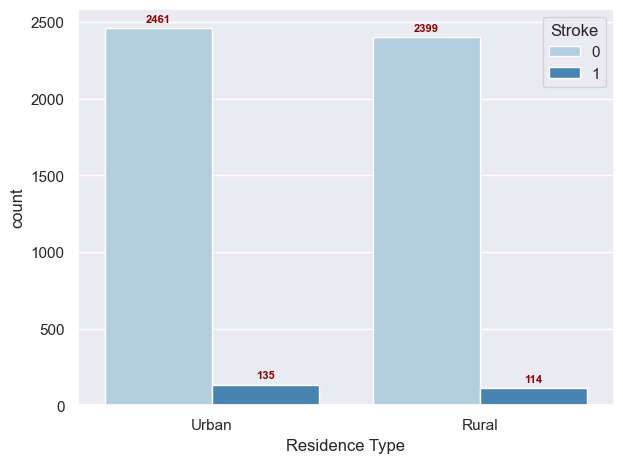

In [132]:
import matplotlib.pyplot as plt
#plt.figure(figsize=(8,4)) #make the plot more visible by increasing height and width
bars= sns.countplot(data = stroke_dset, x= "Residence Type", palette= "Blues", hue ="Stroke",  legend=True)

for i in bars.containers:
  bars.bar_label(i, padding=3, color="darkred",fontweight="bold", fontsize= 8)

plt.tight_layout()
plt.show()

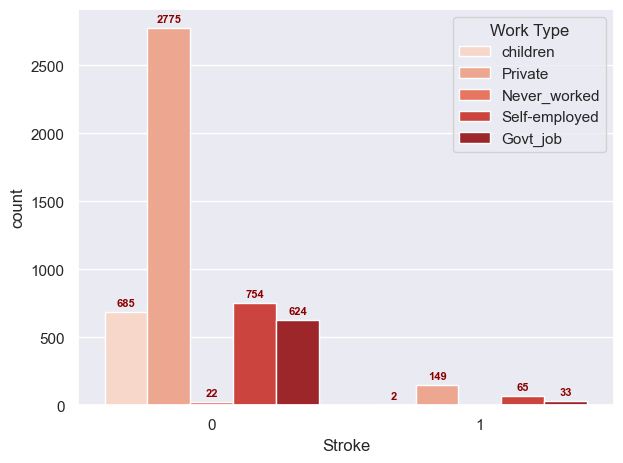

In [134]:
bars= sns.countplot(data = stroke_dset, x= "Stroke", palette= "Reds", hue ="Work Type",  legend=True)

for i in bars.containers:
  bars.bar_label(i, padding=3, color="darkred",fontweight="bold", fontsize= 8)

plt.tight_layout()

plt.show()

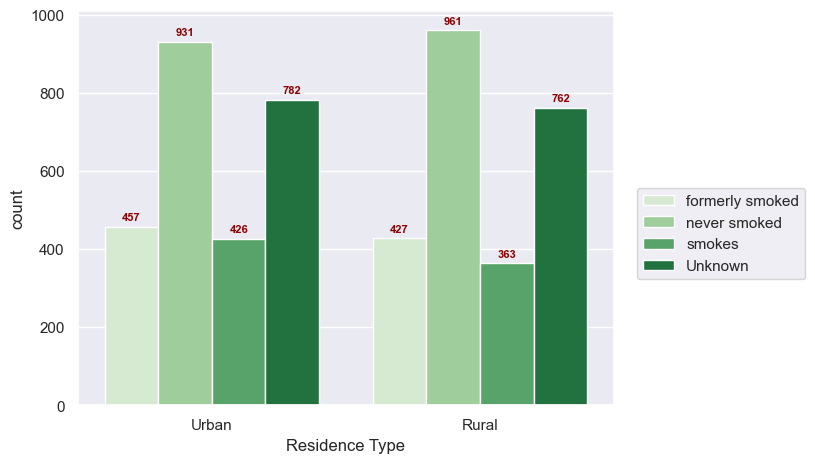

In [155]:
bars= sns.countplot(data = stroke_dset, x= "Residence Type", palette= "Greens", hue ="Smoking Status",  legend=True)

for i in bars.containers:
  bars.bar_label(i, padding=3, color="darkred",fontweight="bold", fontsize= 8)

plt.tight_layout()
plt.legend(bbox_to_anchor=(1.2, .3), loc="lower center")

plt.show()

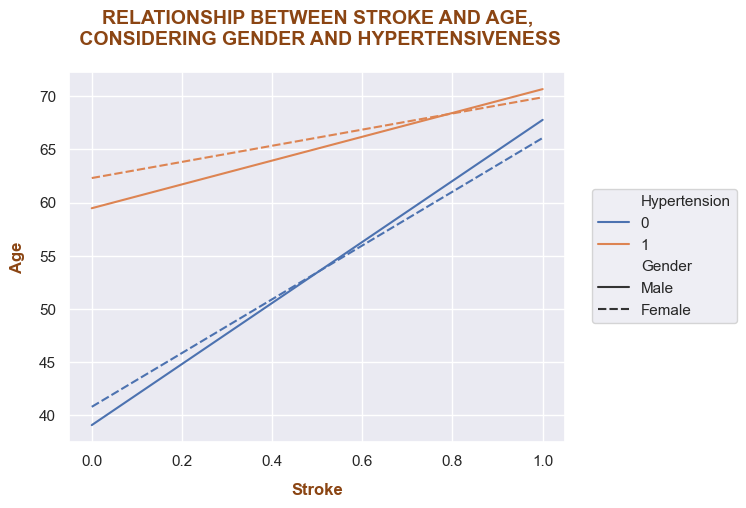

In [158]:
sns.lineplot(data=stroke_dset, x="Stroke", y="Age", hue="Hypertension", style="Gender", errorbar=None)
plt.legend(bbox_to_anchor=(1.2, 0.3), loc="lower center")
plt.xlabel("Stroke", labelpad=10, color = "saddlebrown", fontweight="bold")
plt.ylabel("Age", labelpad=10, color = "saddlebrown", fontweight="bold")
plt.title("RELATIONSHIP BETWEEN STROKE AND AGE,\n CONSIDERING GENDER AND HYPERTENSIVENESS", pad=20, color = "saddlebrown", fontweight = "bold", fontsize= 14)

plt.show()

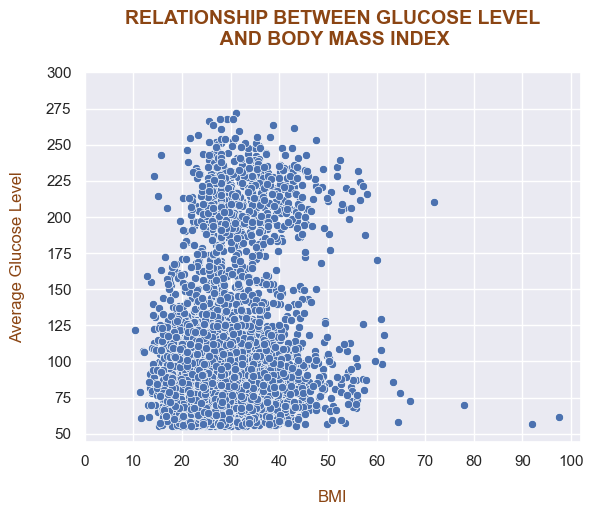

In [130]:
sns.scatterplot(x= stroke_dset["Bmi"], y=stroke_dset["Avg Glucose Level"])
plt.xlabel("BMI", labelpad=15, color = "saddlebrown")
plt.ylabel("Average Glucose Level", labelpad=15, color = "saddlebrown")
plt.title("RELATIONSHIP BETWEEN GLUCOSE LEVEL\n AND BODY MASS INDEX", pad=20, color = "saddlebrown", fontweight = "bold", fontsize=14)
plt.yticks(range(50, 301, 25))
plt.xticks(range(0, 101, 10))

plt.show()

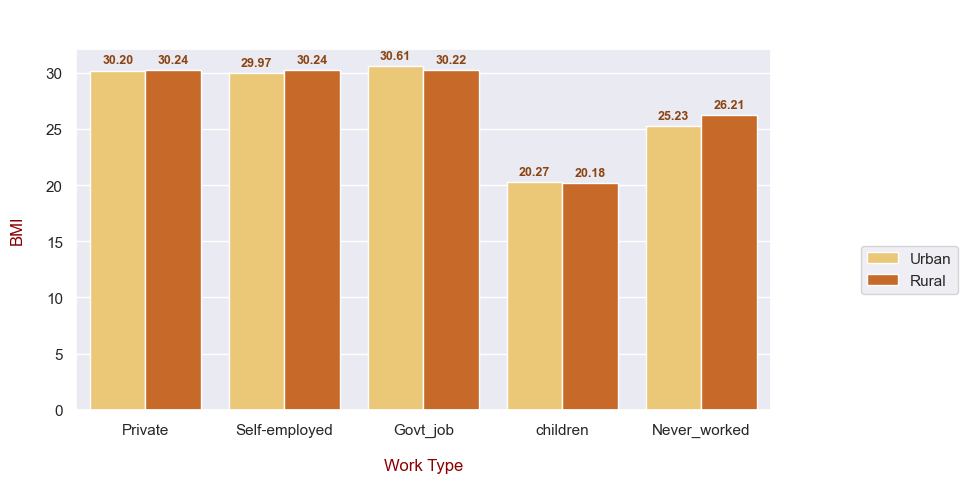

In [197]:
plt.figure(figsize=(10,5)) #make the plot more visible by increasing height and width
bars = sns.barplot(data = stroke_dset, x = "Work Type", y="Bmi", palette = "YlOrBr", hue= "Residence Type", legend= True, errorbar=None)
plt.title(" ", pad=20, color = "darkred", fontweight = "bold")
plt.ylabel("BMI", labelpad=15, color = "darkred")
plt.xlabel ("Work Type", labelpad=15, color = "darkred")
plt.legend(bbox_to_anchor=(1.2, 0.3), loc="lower center")


plt.tight_layout()
for i in bars.containers:
    bars.bar_label(i, fmt="{:,.2f}", padding=3, fontsize=9, fontweight="bold", color= "saddlebrown")

plt.show()

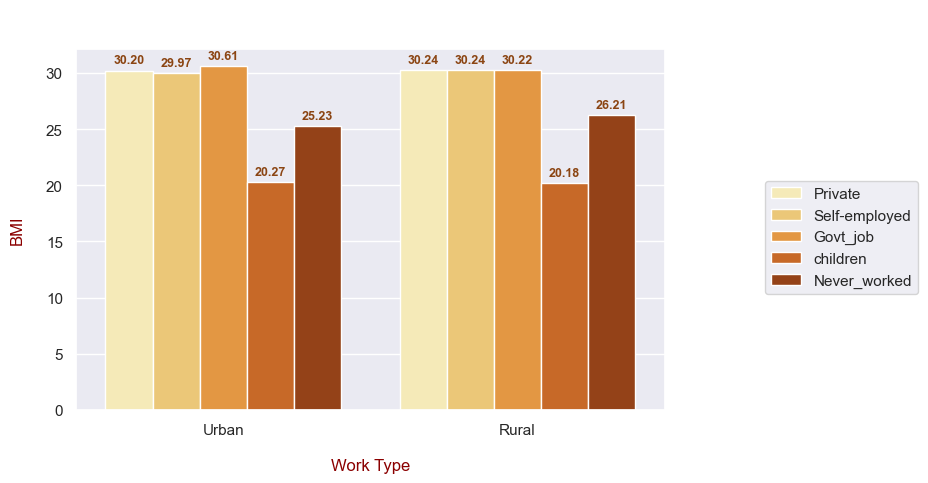

In [195]:
plt.figure(figsize=(10,5))
bars = sns.barplot(data = stroke_dset, x = "Residence Type", y="Bmi", palette = "YlOrBr", hue= "Work Type", legend= True, errorbar=None)
plt.title(" ", pad=20, color = "darkred", fontweight = "bold")
plt.ylabel("BMI", labelpad=15, color = "darkred")
plt.xlabel ("Work Type", labelpad=15, color = "darkred")
plt.legend(bbox_to_anchor=(1.3, 0.3), loc="lower center")

plt.tight_layout()
for i in bars.containers:
    bars.bar_label(i, fmt="{:,.2f}", padding=3, fontsize=9, fontweight="bold", color= "saddlebrown")

plt.show()

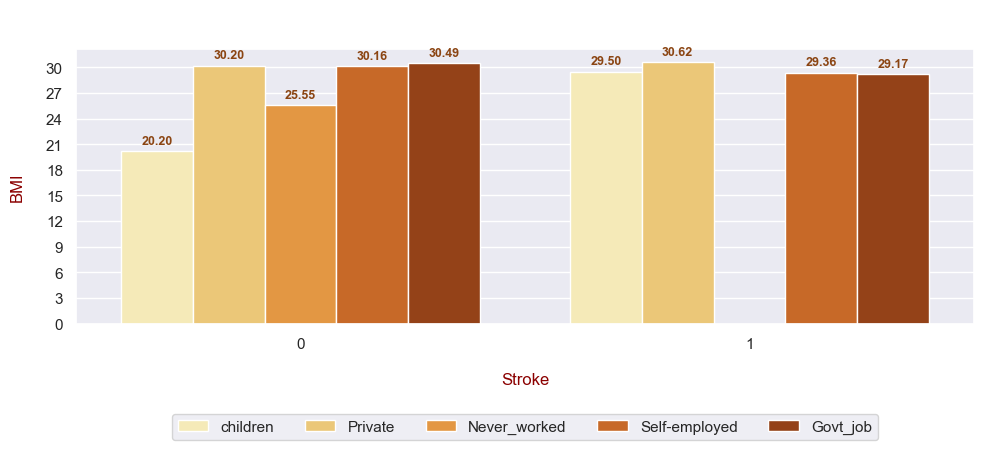

In [191]:
#plt.figure(figsize=(19,8)) #make the plot more visible by increasing height and width
plt.figure(figsize=(10,5))
bars = sns.barplot(data = stroke_dset, x = "Stroke", y="Bmi", palette = "YlOrBr", hue= "Work Type", legend= True, errorbar=None)
plt.title(" ", pad=20, color = "darkred", fontweight = "bold")
plt.ylabel("BMI", labelpad=15, color = "darkred")
plt.xlabel ("Stroke", labelpad=15, color = "darkred")
plt.yticks(range(0, 31, 3))
plt.legend(ncol=5, bbox_to_anchor=(.5, -0.3), loc="upper center")


plt.tight_layout()
for i in bars.containers:
    bars.bar_label(i, fmt="{:,.2f}", padding=3, fontsize=9, fontweight="bold", color= "saddlebrown")

plt.show()

In [90]:
stroke_dset.head()

,Gender,Age,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Avg Glucose Level,Bmi,Smoking Status,Stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
